In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from langdetect import detect

In [3]:
books = pd.read_json("data/goodreads_books_romance.json.gz", lines=True, nrows = 25000) # large data, so only read the the first 25000
reviews = pd.read_json("data/goodreads_reviews_romance.json.gz", lines=True, nrows = 150000) # read first 150000

In [4]:
# print the first two rows to check what the data looks like
books.head(2)

,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,,4,[],US,,"[{'count': '4', 'name': 'to-read'}, {'count': ...",,true,3.86,,...,5,,2017,https://www.goodreads.com/book/show/34883016-p...,https://images.gr-assets.com/books/1493525974m...,34883016,5,56135087,Playmaker: A Venom Series Novella,Playmaker: A Venom Series Novella
1,,21,[811663],US,en-US,"[{'count': '598', 'name': 'to-read'}, {'count'...",B01BLJGA9S,true,4.23,B01BLJGA9S,...,,,,https://www.goodreads.com/book/show/29074693-p...,https://s.gr-assets.com/assets/nophoto/book/11...,29074693,149,46079519,"Prowled Darkness (Dante's Circle, #7)","Prowled Darkness (Dante's Circle, #7)"


In [5]:
#prints all unique languages of each book in the df
books['language_code'].unique()

array(['', 'en-US', 'eng', 'en-GB', 'ger', 'ita', 'jpn', 'en-CA', 'ind',
       'por', 'spa', 'rus', 'fre', 'bul', 'cze', 'ben', 'slo', 'ara',
       'tur', 'hun', 'nl', 'est', 'fil', 'pol', 'swe', 'rum', 'vie',
       'tha', 'msa', 'gre', 'nor', 'fin', 'scr', 'per', 'dan', 'srp',
       'heb', 'es-MX', 'urd', 'zho', 'lav', 'cat', 'lit', 'tgl', 'slv',
       'kat', 'en', 'bos', 'mul', 'hin', 'kor', 'abk', 'tel', 'jav', '--',
       'din', 'mal', 'pt-BR', 'aze', 'nno'], dtype=object)

In [6]:
# keep the book rows where the language is english
eng_books = books[books['language_code'].str.match('en')]

In [7]:
# US, Canadian, and Great Britain english only
eng_books['language_code'].unique()

array(['en-US', 'eng', 'en-GB', 'en-CA', 'en'], dtype=object)

In [8]:
# keep only the reviews related to the books in the book dataframe
id_list = eng_books['book_id'].tolist()
reviews = reviews[reviews['book_id'].isin(id_list)]

**Data Cleaning**

In [9]:
books.columns

Index(['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code',
       'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin',
       'similar_books', 'description', 'format', 'link', 'authors',
       'publisher', 'num_pages', 'publication_day', 'isbn13',
       'publication_month', 'edition_information', 'publication_year', 'url',
       'image_url', 'book_id', 'ratings_count', 'work_id', 'title',
       'title_without_series'],
      dtype='object')

In [10]:
reviews.columns

Index(['user_id', 'book_id', 'review_id', 'rating', 'review_text',
       'date_added', 'date_updated', 'read_at', 'started_at', 'n_votes',
       'n_comments'],
      dtype='object')

In [11]:
reviews = reviews.iloc[:, 0:7] # keep the first 7 columns
eng_books = eng_books[['book_id', 'title']] # only keep the book_id and title 

In [12]:
reviews = reviews[~reviews['review_text'].str.match('http')] # exclude reviews that include links to a website
reviews = reviews[reviews['review_text'] != ''] # exclude blank reviews

**EDA**

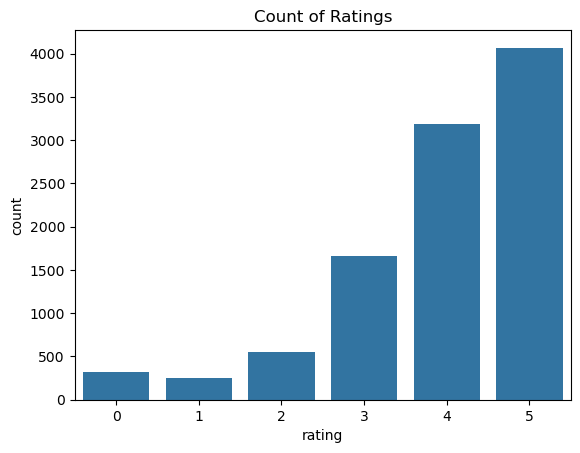

In [13]:
sns.countplot(reviews, x='rating').set_title('Count of Ratings')
plt.show()

In [14]:
rating_counts = reviews.groupby(['book_id', 'rating']).size().reset_index(name='count') 
pivot_ratings = rating_counts.pivot(index='book_id', columns='rating', values='count').fillna(0).astype(int) # counts how many times a book got a specific rating


In [15]:
pivot_ratings.head()

rating,0,1,2,3,4,5
book_id,,,,,,
9553,0,0,1,1,2,2
11339,0,0,0,0,1,1
22205,1,1,3,3,16,8
26046,0,2,2,0,2,2
26049,0,0,0,0,0,1


In [16]:
merged_book_ratings = pd.merge(eng_books, pivot_ratings, on='book_id', how='left').fillna(0)

In [17]:
merged_book_ratings.sort_values(by=5, ascending=False).head() # sort books with the most 5-star rating to the least

,book_id,title,0,1,2,3,4,5
12540,15507958,"Me Before You (Me Before You, #1)",8.0,7.0,8.0,29.0,95.0,155.0
2667,13372690,"Slammed (Slammed, #1)",1.0,0.0,2.0,9.0,19.0,118.0
8929,16081272,"The Edge of Never (The Edge of Never, #1)",1.0,0.0,4.0,9.0,20.0,114.0
2686,16113791,The Coincidence of Callie & Kayden (The Coinci...,1.0,4.0,3.0,6.0,23.0,67.0
1187,6936382,Anna and the French Kiss (Anna and the French ...,1.0,3.0,9.0,25.0,41.0,60.0


**Language Detection for Reviews**

In [18]:
# helper function to identify the language of text
def text_detect(text):
    try:
        return detect(text)
    except:
        return None

In [19]:
sample_rev = reviews.copy()
sample_rev['lang'] = sample_rev['review_text'].apply(text_detect)

In [20]:
# check to make sure all reviews are in english
sample_rev['lang'].unique()

array(['en', None, 'de', 'es', 'sv', 'fi', 'af', 'pt', 'no', 'ro', 'da',
       'tl', 'cy', 'it', 'et', 'so', 'vi', 'tr', 'id', 'sq', 'fr', 'nl',
       'pl', 'sl', 'ca', 'cs', 'lv', 'hu', 'sw', 'hr'], dtype=object)

In [21]:
sample_rev = sample_rev[sample_rev['lang'] == 'en'] # keep only the english reviews

**NLTK**

In [22]:
random_rev = sample_rev.sample(n=1) # choose a random row
example = random_rev['review_text'].values[0]

In [23]:
# example of a review for visual purposes
print(example)

I will truly say out of the entire series, aside from book one, this was my absolute favorite. Great storyline, great characters, great ending. 
 Totally loved Bree from the second I read about her. I absolutely loved the fact that in this book the couples weren't in denial and together the entire time. There were some amazing erotic scenes, and I just can't get enough of the Anderson family. This book was full of action and although there were some very predictable scene(amnesia and charlie), it still did a great Job at action and suspense. Of the entire series, by far the best, a whole lot more storyline to this book.


In [24]:
# print the title of the book related to this review
ex_id = random_rev['book_id'].values[0]
eng_books[eng_books['book_id'] == ex_id]['title'].values[0]

'Runaway Heiress (Billionaire Bachelors, #6)'

In [25]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['I', 'will', 'truly', 'say', 'out', 'of', 'the', 'entire', 'series', ',']

In [26]:
tags = nltk.pos_tag(tokens)
tags[:10]

[('I', 'PRP'),
 ('will', 'MD'),
 ('truly', 'VB'),
 ('say', 'VB'),
 ('out', 'IN'),
 ('of', 'IN'),
 ('the', 'DT'),
 ('entire', 'JJ'),
 ('series', 'NN'),
 (',', ',')]

In [27]:
entities = nltk.chunk.ne_chunk(tags)
entities.pprint()

(S
  I/PRP
  will/MD
  truly/VB
  say/VB
  out/IN
  of/IN
  the/DT
  entire/JJ
  series/NN
  ,/,
  aside/RB
  from/IN
  book/NN
  one/CD
  ,/,
  this/DT
  was/VBD
  my/PRP$
  absolute/JJ
  favorite/NN
  ./.
  (GPE Great/NNP)
  storyline/NN
  ,/,
  great/JJ
  characters/NNS
  ,/,
  great/JJ
  ending/VBG
  ./.
  Totally/RB
  loved/JJ
  Bree/NNP
  from/IN
  the/DT
  second/JJ
  I/PRP
  read/VBP
  about/IN
  her/PRP
  ./.
  I/PRP
  absolutely/RB
  loved/VBD
  the/DT
  fact/NN
  that/IN
  in/IN
  this/DT
  book/NN
  the/DT
  couples/NNS
  were/VBD
  n't/RB
  in/IN
  denial/JJ
  and/CC
  together/RB
  the/DT
  entire/JJ
  time/NN
  ./.
  There/EX
  were/VBD
  some/DT
  amazing/JJ
  erotic/JJ
  scenes/NNS
  ,/,
  and/CC
  I/PRP
  just/RB
  ca/MD
  n't/RB
  get/VB
  enough/RB
  of/IN
  the/DT
  (PERSON Anderson/NNP)
  family/NN
  ./.
  This/DT
  book/NN
  was/VBD
  full/JJ
  of/IN
  action/NN
  and/CC
  although/IN
  there/EX
  were/VBD
  some/DT
  very/RB
  predictable/JJ
  scene/NN
  (/(
  a

**VADER Sentiment Scoring**

In [28]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [29]:
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.711, 'pos': 0.289, 'compound': 0.991}

**Polarity Scores**

In [30]:
results = {} # stores a dictionary where the key is the review ID and the value is the polarity scores
for i, row in tqdm(sample_rev.iterrows(), total = len(sample_rev)):
    text = row['review_text']
    rev_id = row['review_id']
    results[rev_id] = sia.polarity_scores(text)

  0%|          | 0/9476 [00:00<?, ?it/s]

In [31]:
vaders = pd.DataFrame(results).T
vaders = vaders.reset_index().rename(columns={'index': 'review_id'})
vaders.head()

,review_id,neg,neu,pos,compound
0,63ff74279e46b247cb1754313b160006,0.000,0.902,0.098,0.3612
1,f4892dda2f239e516e7f195b31a6fc18,0.073,0.666,0.260,0.9977
2,5bdbfd274ccd2ed0e43a9efb7b770e92,0.057,0.756,0.187,0.9932
3,108176b79943cee4050b0b1d497c0a6c,0.106,0.755,0.139,0.8934
4,5308f2e435ed92c1630c0d9ead959641,0.071,0.733,0.196,0.9982


In [32]:
review_sentiment = pd.merge(vaders, sample_rev, on='review_id', how='left')
review_sentiment[['compound', 'review_text', 'rating']].sort_values(by='compound').head(15)

,compound,review_text,rating
2880,-0.9997,UPDATE for you guys! LD has posted some snippe...,5
3129,-0.9985,ARC provided by author in exchange for an hone...,5
2844,-0.9985,3.5 stars \n Reviewed by: Rabid Reads \n A Hun...,3
5105,-0.9985,I'm feeling really betrayed by those who said ...,1
6446,-0.9978,4.5 Find Your Family Stars \n Sometimes you ha...,5
7551,-0.9976,Oh god. WTF is wrong with romance novelists? I...,1
1349,-0.9962,ARC provided by Shadow Mountain through Netgal...,2
5583,-0.9962,I watched the movie because of Colin Firth <3 ...,2
1773,-0.9959,I waited for what felt like forever to read th...,5
6680,-0.9955,"What. A. Bitch. \n I'm sorry, but no. The main...",1


**Plotting Results**

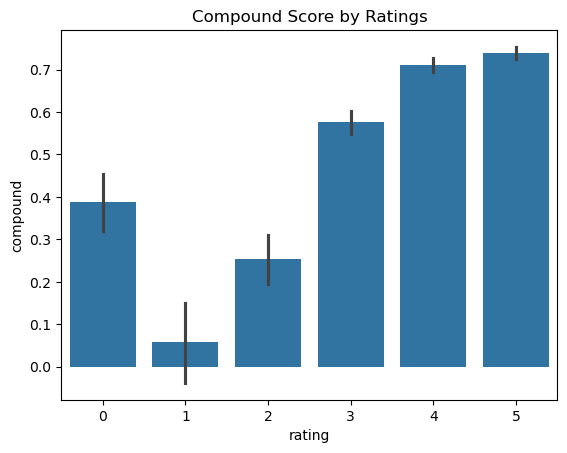

In [33]:
ax = sns.barplot(data=review_sentiment, x='rating', y='compound')
ax.set_title("Compound Score by Ratings")
plt.show()

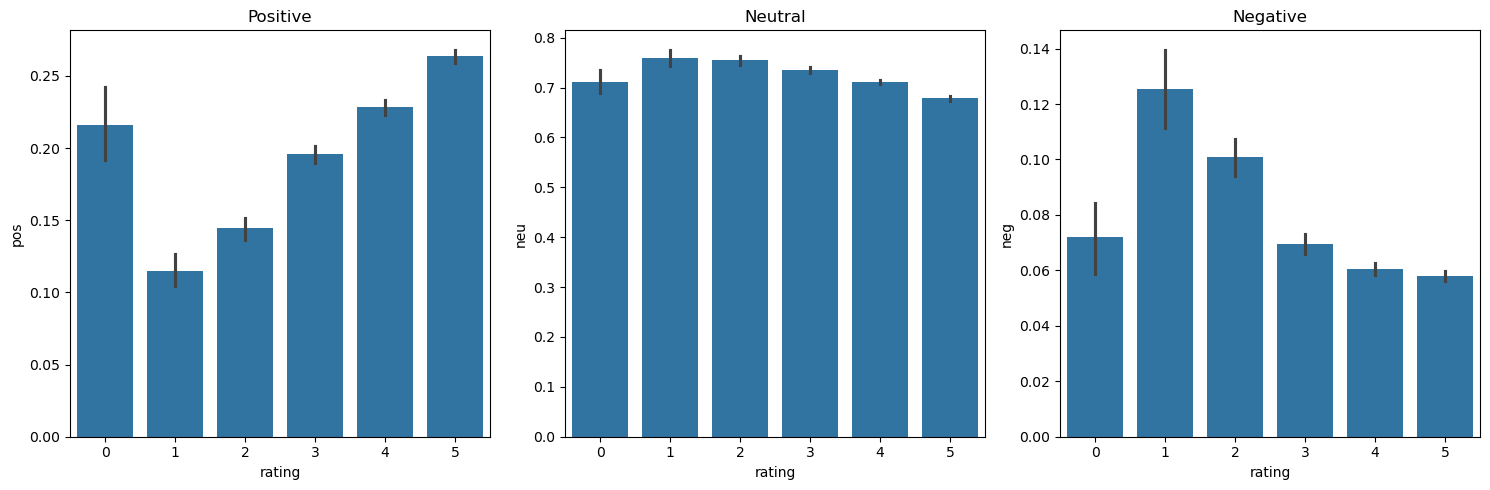

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(data=review_sentiment, x='rating', y='pos', ax=axs[0])
sns.barplot(data=review_sentiment, x='rating', y='neu', ax=axs[1])
sns.barplot(data=review_sentiment, x='rating', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

**Roberta Pretrained Model**

In [35]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

In [36]:
# pretrained model
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [37]:
print(example)

I will truly say out of the entire series, aside from book one, this was my absolute favorite. Great storyline, great characters, great ending. 
 Totally loved Bree from the second I read about her. I absolutely loved the fact that in this book the couples weren't in denial and together the entire time. There were some amazing erotic scenes, and I just can't get enough of the Anderson family. This book was full of action and although there were some very predictable scene(amnesia and charlie), it still did a great Job at action and suspense. Of the entire series, by far the best, a whole lot more storyline to this book.


In [38]:
#roberta model on one example
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'r_neg' : scores[0],
    'r_neu' : scores[1],
    'r_pos' : scores[2]
}
print(scores_dict)

{'r_neg': 0.0022930084, 'r_neu': 0.007924354, 'r_pos': 0.9897827}


In [39]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt', truncation=True)
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'r_neg' : scores[0],
        'r_neu' : scores[1],
        'r_pos' : scores[2]
    }
    return scores_dict

In [40]:
# sentiment analysis on both Vader and RoBERTa on 500 sampled reviews
all_res = {}
error_reviews = []
small_rev = sample_rev.sample(n=500)
for i, row in tqdm(small_rev.iterrows(), total = len(small_rev)):
    try:
        text = row['review_text']
        id = row['review_id']
        vader_res = sia.polarity_scores(text)
        vader_renamed = {}
        for key, value in vader_res.items():
            vader_renamed[f'v_{key}'] = value

        roberta_res = polarity_scores_roberta(text)
        both_res = {**vader_renamed, **roberta_res} 

        all_res[id] = both_res
    except Exception as e:
        error_reviews.append((id, str(e)))

  0%|          | 0/500 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [41]:
sentiment_df = pd.DataFrame(all_res).T
sentiment_df = sentiment_df.reset_index().rename(columns={'index' : 'review_id'})
sentiment_df = pd.merge(sentiment_df, small_rev, on='review_id', how='left')

In [42]:
sentiment_df.head(1)

,review_id,v_neg,v_neu,v_pos,v_compound,r_neg,r_neu,r_pos,user_id,book_id,rating,review_text,date_added,date_updated,lang
0,c5c197a92e01cf93ad88f48e5c6821cb,0.133,0.801,0.065,-0.8342,0.415137,0.435204,0.14966,eaeb06afd26acaf0a4f32483e602f33e,18072325,4,3.5 stars \n This was a 4 star book for me unt...,Sun Oct 06 17:54:35 -0700 2013,Tue Oct 08 06:55:07 -0700 2013,en


**Comparison**

In [43]:
# most positive one star rating for roberta
sentiment_df.query('rating == 1').sort_values('r_pos', ascending=False)['review_text'].values[0]

"DNF at 40% \n I loved Jessica Park's other books, but this was had too much inner dialogue, plus I felt like the heroine liked the hero more than the other way around. May work for you, but did not work for me. \n I loved Chris's sibilings!"

In [44]:
# most positive one star rating for vader
sentiment_df.query('rating == 1').sort_values('v_pos', ascending=False)['review_text'].values[0]

"DNF at 40% \n I loved Jessica Park's other books, but this was had too much inner dialogue, plus I felt like the heroine liked the hero more than the other way around. May work for you, but did not work for me. \n I loved Chris's sibilings!"

In [45]:
# most negative five star rating for roberta
sentiment_df.query('rating == 5').sort_values('r_neg', ascending=False)['review_text'].values[0]

"This Book. It is one of those books, where you can't quite figure out why you keep putting yourself through all this emotional turmoil. You know you are going to ugly cry, you know you are going to swear to never read these types of books again, but yet you keep coming back. \n This book was so emotionally beautiful, but it was also so ugly. Ugly because people in life can be so cruel. People judge skin color and not actions. They judge life based on you status and physical appearance instead of your actions and morals. \n This story was hard to swallow, Caroline had it rough. From a young child it was one pain after the next, after the next, after the NEXT! This poor girl never caught a break. From mental and physical abuse, to finding happiness only to have it ripped away. I can't say I agree with some of the methods in this book, I can say life is hard. It's not what happens to you that defines you, but how you react to the things that make you. Another highly recommended book!"

In [46]:
# most negative five star rating for vader
sentiment_df.query('rating == 5').sort_values('v_neg', ascending=False)['review_text'].values[0]

'Damn Damn this book had me on pins and needles love this book'